<a href="https://colab.research.google.com/github/rayanedesouza96/uenf_2026_geomodelagem/blob/main/Acai%2Bbarbeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# 1. Instalação das bibliotecas
# =========================================================
!pip install roboflow
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.1 MB/s eta 0:00:00


In [30]:
# =========================================================
# 2. Configuração única do Roboflow (SUA IDENTIDADE - usada apenas aqui)
# =========================================================
from roboflow import Roboflow

ROBOFLOW_API_KEY = "IkkUg760C8dI669IZBxo"
WORKSPACE = "rayanes-workspace-emhhr"
PROJECT_NAME = "teste-esd8a"
VERSION = 5

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)

# Opcional: listar versões disponíveis do projeto
print(f"Versões disponíveis para o projeto '{project.name}':")
for v in project.versions():
    print(f"- Versão {v.version}: {v.name}")

loading Roboflow workspace...
loading Roboflow project...
Versões disponíveis para o projeto 'teste':
- Versão 1352795641: teste
- Versão 5: teste
- Versão 4: teste
- Versão 3: teste
- Versão 2: teste
- Versão 1: teste


In [31]:
# =========================================================
# 3. Download do dataset (açaí + barbeiro)
# =========================================================
version = project.version(VERSION)
dataset = version.download("yolov11")

print("Dataset baixado em:", dataset.location)


Extracting Dataset Version Zip to teste-5 in yolov11:: 100%|██████████| 123/123 [00:00<00:00, 3657.82it/s]

Dataset baixado em: /content/teste-5


In [32]:
# =========================================================
# 4. Ajuste do data.yaml (caminhos absolutos corretos)
# =========================================================
import os
import yaml

data_yaml_path = os.path.join(dataset.location, 'data.yaml')

with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Remove a entrada 'path' problemática, se existir
if 'path' in data_config:
    print(f"Removendo a entrada 'path' problemática do data.yaml: {data_config['path']}")
    del data_config['path']

if 'train' in data_config:
    data_config['train'] = os.path.join(dataset.location, 'train')
if 'val' in data_config:
    # O Roboflow costuma nomear a pasta de validação como 'valid'
    data_config['val'] = os.path.join(dataset.location, 'valid')
if 'test' in data_config:
    data_config['test'] = os.path.join(dataset.location, 'test')

print("Classes detectadas no dataset:", data_config.get('names'))
print("Número de classes:", data_config.get('nc'))

# Salva o data.yaml ajustado
temp_data_yaml_path = os.path.join(dataset.location, 'data_modified_ultralytics.yaml')
with open(temp_data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"data.yaml modificado salvo em: {temp_data_yaml_path}")
print("Conteúdo do data.yaml modificado:")
with open(temp_data_yaml_path, 'r') as f:
    print(f.read())

Classes detectadas no dataset: ['acai', 'barbeiro']
Número de classes: 2
data.yaml modificado salvo em: /content/teste-5/data_modified_ultralytics.yaml
Conteúdo do data.yaml modificado:
names:
- acai
- barbeiro
nc: 2
roboflow:
  license: CC BY 4.0
  project: teste-esd8a
  url: https://universe.roboflow.com/rayanes-workspace-emhhr/teste-esd8a/dataset/5
  version: 5
  workspace: rayanes-workspace-emhhr
test: /content/teste-5/test
train: /content/teste-5/train
val: /content/teste-5/valid



In [33]:
# =========================================================
# 5. Treinamento do modelo (açaí + barbeiro)
# =========================================================
from ultralytics import YOLO

model = YOLO("yolo11l-seg.pt")  # modelo base de segmentação

model.train(
    data=temp_data_yaml_path,
    epochs=30,        # <<< ALTERADO: era 5, aumentado para o modelo aprender melhor
    imgsz=960,         # <<< ALTERADO: era 640 (você já tinha mudado no seu ambiente)
    batch=16,
    workers=8,
    patience=10,       # <<< NOVO: para o treino cedo se não melhorar em 10 épocas seguidas
    seed=42,           # <<< NOVO: fixa a semente para resultados reproduzíveis
    project=PROJECT_NAME,
    name="exp_acai_barbeiro"
)

# <<< CORRIGIDO: pega o caminho do best.pt dinamicamente (não hardcoded),
# pois o Ultralytics salva em runs/segment/... e adiciona sufixo (-2, -3, -4...)
# toda vez que a pasta já existe de um treino anterior
best_model_path = model.trainer.best
model = YOLO(best_model_path)
print(f"Melhor modelo carregado de: {best_model_path}")

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/teste-5/data_modified_ultralytics.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_acai_barbeiro-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l-seg summary (fused): 204 layers, 27,586,905 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2086.9±1343.4 MB/s, size: 184.0 KB)
val: Scanning /content/teste-4/valid/labels.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.1it/s 0.9s
                   all          4          5      0.794      0.556      0.541      0.444      0.463      0.889       0.87      0.508
                  acai          1          1      0.939          1      0.995      0.895       0.27          1      0.995      0.597
              barbeiro          1          1          1          0    0.00143    0.00043       0.79          1      0.995      0.497
                 teste          3          3    

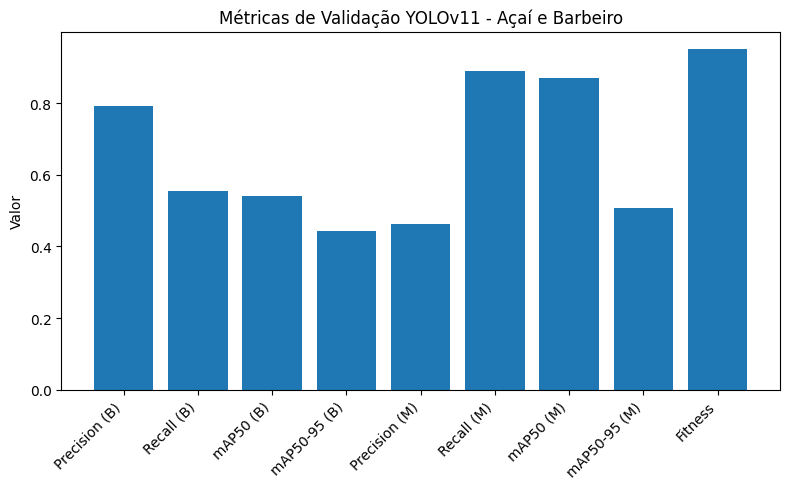

In [28]:
# =========================================================
# 6. Validação e métricas
# =========================================================
metrics = model.val(data=temp_data_yaml_path)
print(metrics)

import matplotlib.pyplot as plt

labels_map = {
    "metrics/precision(B)": "Precision (B)",
    "metrics/recall(B)": "Recall (B)",
    "metrics/mAP50(B)": "mAP50 (B)",
    "metrics/mAP50-95(B)": "mAP50-95 (B)",
    "metrics/precision(M)": "Precision (M)",
    "metrics/recall(M)": "Recall (M)",
    "metrics/mAP50(M)": "mAP50 (M)",
    "metrics/mAP50-95(M)": "mAP50-95 (M)",
    "fitness": "Fitness"
}

keys = list(metrics.results_dict.keys())
values = list(metrics.results_dict.values())
labels = [labels_map.get(k, k) for k in keys]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Valor")
plt.title("Métricas de Validação YOLOv11 - Açaí e Barbeiro")
plt.tight_layout()
plt.show()

In [39]:
# =========================================================
# 7. Predição em novas imagens
# =========================================================
import glob

# Pega automaticamente a primeira imagem da pasta de teste do dataset
# (não precisa informar nenhum caminho - já usa o dataset baixado na seção 3)
test_images = glob.glob(os.path.join(dataset.location, "test", "images", "*.*"))
print(f"Encontradas {len(test_images)} imagens de teste")

results = model.predict(test_images[0], save=True, conf=0.15, iou=0.4)

# Mostrar máscaras/detecções (açaí e barbeiro)
results[0].plot()

Encontradas 1 imagens de teste

image 1/1 /content/teste-5/test/images/4_png.rf.6ca19903ba4714e67108d6ae91ea2992.jpg: 736x960 1 acai, 1 barbeiro, 98.1ms
Speed: 4.8ms preprocess, 98.1ms inference, 2.1ms postprocess per image at shape (1, 3, 736, 960)
Results saved to /content/runs/segment/predict-5


array([[[143, 177, 167],
        [143, 177, 167],
        [143, 174, 165],
        ...,
        [159, 182, 178],
        [165, 188, 184],
        [171, 194, 190]],

       [[145, 179, 169],
        [144, 178, 168],
        [145, 176, 167],
        ...,
        [152, 175, 171],
        [157, 180, 176],
        [163, 186, 182]],

       [[149, 180, 171],
        [148, 179, 170],
        [148, 177, 168],
        ...,
        [147, 168, 165],
        [152, 173, 170],
        [156, 177, 174]],

       ...,

       [[142, 185, 204],
        [140, 183, 202],
        [136, 179, 198],
        ...,
        [168, 123, 110],
        [255,  42,   4],
        [255,  42,   4]],

       [[129, 175, 192],
        [126, 172, 189],
        [121, 167, 184],
        ...,
        [255,  42,   4],
        [255,  42,   4],
        [255,  42,   4]],

       [[120, 166, 183],
        [116, 162, 179],
        [111, 157, 174],
        ...,
        [255,  42,   4],
        [255,  42,   4],
        [255,  42,   4]]